# 🌸 Iris Flower Classification using K-Nearest Neighbors (KNN)
This notebook implements the KNN algorithm on the Iris dataset.

## Step 1: Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    

## Step 2: Load and Inspect Dataset

In [2]:

df = pd.read_csv("Iris.csv")
df.drop("Id", axis=1, inplace=True)
df.head()
    

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Step 3: Encode Target Labels

In [3]:

# Convert Species column to numeric
df['Species'] = df['Species'].astype('category').cat.codes
df.head()
    

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Step 4: Split Data

In [4]:

X = df.drop('Species', axis=1)
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    

## Step 5: Normalize Features

In [5]:

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
    

## Step 6: Train and Evaluate KNN (Try Different K Values)

K=1 => Accuracy: 1.00
K=2 => Accuracy: 1.00
K=3 => Accuracy: 1.00
K=4 => Accuracy: 1.00
K=5 => Accuracy: 1.00
K=6 => Accuracy: 1.00
K=7 => Accuracy: 1.00
K=8 => Accuracy: 1.00
K=9 => Accuracy: 1.00
K=10 => Accuracy: 1.00


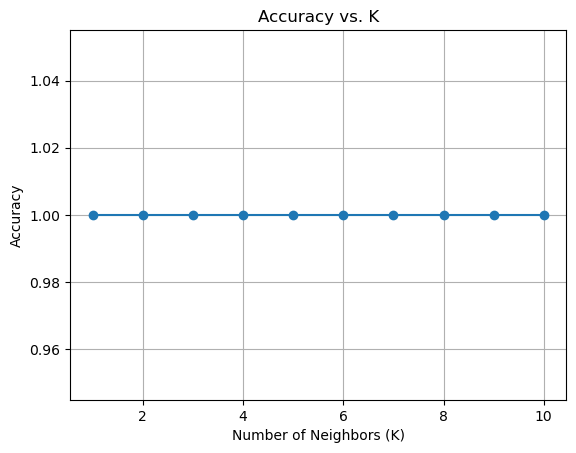

In [6]:

k_values = list(range(1, 11))
accuracy_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracy_scores.append(acc)
    print(f"K={k} => Accuracy: {acc:.2f}")

# Plot accuracy vs. K
plt.plot(k_values, accuracy_scores, marker='o')
plt.title("Accuracy vs. K")
plt.xlabel("Number of Neighbors (K)")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()
    

## Step 7: Evaluate Final Model (Best K)

In [7]:

best_k = k_values[np.argmax(accuracy_scores)]
print(f"Best K = {best_k}")

knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)
y_pred_final = knn_final.predict(X_test_scaled)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_final))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_final))
    

Best K = 1
Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## Step 8: Bonus — 2D Visualization (Petal Features Only)

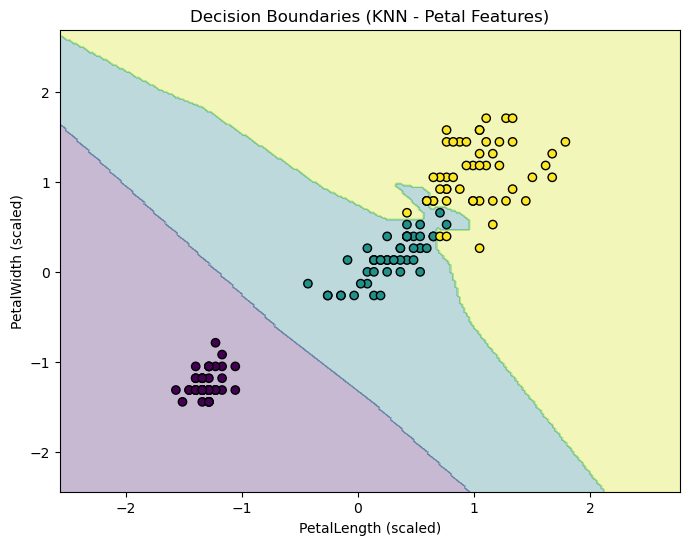

In [8]:

# Plot using only PetalLength and PetalWidth
X_vis = df[['PetalLengthCm', 'PetalWidthCm']].values
y_vis = df['Species']

scaler_vis = StandardScaler()
X_vis_scaled = scaler_vis.fit_transform(X_vis)

X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(X_vis_scaled, y_vis, test_size=0.2, random_state=42)

model_2d = KNeighborsClassifier(n_neighbors=best_k)
model_2d.fit(X_train_v, y_train_v)

# Create a mesh grid
x_min, x_max = X_vis_scaled[:, 0].min() - 1, X_vis_scaled[:, 0].max() + 1
y_min, y_max = X_vis_scaled[:, 1].min() - 1, X_vis_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_vis_scaled[:, 0], X_vis_scaled[:, 1], c=y_vis, edgecolor='k')
plt.xlabel("PetalLength (scaled)")
plt.ylabel("PetalWidth (scaled)")
plt.title("Decision Boundaries (KNN - Petal Features)")
plt.show()
    